# Task 2: BERT-based Sentiment Analysis
## Amazon Fine Food Reviews

**Course:** Data Mining Project  
**Dataset:** Amazon Fine Food Reviews (Kaggle)  
**Model:** BERT via HuggingFace Transformers

---

## 1. Introduction

### What is Sentiment Analysis?
Sentiment analysis is the process of automatically identifying the emotional tone or opinion expressed in a piece of text. Given a review or comment, the goal is to classify it as positive, neutral, or negative.

### Why is it Important for Food Recommendation Systems?
In food delivery and e-commerce platforms, customers leave thousands of reviews every day. Relying on star ratings alone is insufficient because a rating does not explain *why* a customer liked or disliked a product. Sentiment analysis allows us to:
* Automatically understand the context of customer feedback.
* Identify high-quality products to recommend with confidence.
* Filter out products that consistently receive negative text feedback despite average ratings.
* Improve the overall customer experience by surfacing items people actually enjoy.

### What This Notebook Will Do
1. **Load and preprocess** the dataset (removing unnecessary columns and null values).
2. **Convert** star ratings into true sentiment labels.
3. **Clean text** using a minimal approach tailored for BERT.
4. **Apply pre-trained BERT** to classify review text and extract confidence scores.
5. **Evaluate** the model accurately (filtering out neutral reviews).
6. **Perform Error Analysis** to understand model limitations.
7. **Integrate** the sentiment results into a business recommendation logic.

---

## 2. Import Libraries

We import all required libraries upfront. This includes data handling, visualization, evaluation, and the HuggingFace BERT pipeline.

In [1]:
# Standard data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning evaluation
from sklearn.metrics import classification_report, confusion_matrix

# HuggingFace transformers for BERT
from transformers import pipeline

# Text utilities
import re
import warnings
warnings.filterwarnings('ignore')

# Set a consistent plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully.')

All libraries imported successfully.


## 3. Load Dataset

We load the Amazon Fine Food Reviews dataset from a CSV file. This dataset is publicly available on Kaggle and contains over 500,000 food product reviews from Amazon.

**Key columns in the dataset:**

| Column | Description |
|---|---|
| `Id` | Row identifier |
| `ProductId` | Unique product identifier |
| `UserId` | Unique user identifier |
| `Score` | Star rating from 1 to 5 |
| `Summary` | Short review headline |
| `Text` | Full review text |
| `Time` | Unix timestamp of review |

For this task, we will use only `Text` and `Score`.

---

In [2]:
# Load the full dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews/Reviews.csv')

# Show full dataset with all columns before any selection
print('--- Full Dataset (Before Column Selection) ---')
display(df.head(3))
print(f'Original Shape: {df.shape}')
print()
print('Column names and data types:')
print(df.dtypes)

--- Full Dataset (Before Column Selection) ---


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


Original Shape: (568454, 10)

Column names and data types:
Id                         int64
ProductId                 object
UserId                    object
ProfileName               object
HelpfulnessNumerator       int64
HelpfulnessDenominator     int64
Score                      int64
Time                       int64
Summary                   object
Text                      object
dtype: object


In [3]:
# Keep only the two columns needed for sentiment analysis:
# - Text: the actual review content
# - Score: the star rating (1-5) used as ground truth
df = df[['Text', 'Score']].copy()

# Drop rows with missing values in these critical columns
# BERT requires valid text input; null values will cause runtime errors
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('--- Dataset After Column Selection ---')
display(df.head(5))
print(f'Shape after selection: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

--- Dataset After Column Selection ---


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


Shape after selection: (568454, 2)
Missing values remaining: 0


## 4. Data Preprocessing

We convert the numeric `Score` column into categorical sentiment labels so we can compare them against BERT predictions.

**Mapping rule:**
* Score 1-2 → negative
* Score 3  → neutral
* Score 4-5 → positive

**Note on Class Imbalance:**
The dataset is heavily skewed toward positive reviews (approximately 78-80%). This reflects a common e-commerce pattern where satisfied customers leave the most reviews. We must keep this in mind during evaluation.

---

In [4]:
# Map numeric Score to sentiment labels
def map_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

# Apply the mapping to create a new column
df['true_sentiment'] = df['Score'].apply(map_sentiment)

# Show the mapping table clearly
print('Score to Sentiment Mapping Table:')
display(df[['Score', 'true_sentiment']].drop_duplicates().sort_values('Score').reset_index(drop=True))

# Show class distribution counts
print('\nClass Distribution Count:')
print(df['true_sentiment'].value_counts())

Score to Sentiment Mapping Table:


,Score,true_sentiment
0,1,negative
1,2,negative
2,3,neutral
3,4,positive
4,5,positive



Class Distribution Count:
true_sentiment
positive    443777
negative     82037
neutral      42640
Name: count, dtype: int64


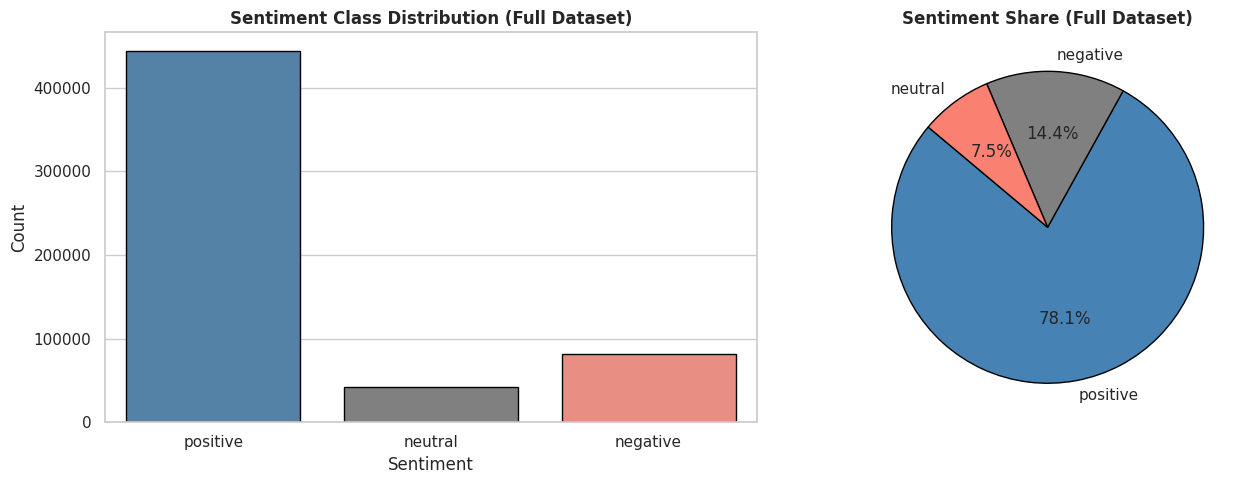

Note: The dataset is heavily skewed toward positive reviews.


In [5]:
# Visualize the class distribution with a bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['positive', 'neutral', 'negative']
colors = ['steelblue', 'gray', 'salmon']

# Bar chart
sns.countplot(
    x='true_sentiment', data=df,
    order=order, palette=colors,
    edgecolor='black', ax=axes[0]
)
axes[0].set_title('Sentiment Class Distribution (Full Dataset)', fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Pie chart
counts = df['true_sentiment'].value_counts()
axes[1].pie(
    counts, labels=counts.index,
    autopct='%1.1f%%', colors=colors,
    startangle=140, wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Sentiment Share (Full Dataset)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Note: The dataset is heavily skewed toward positive reviews.')

## 5. Data Sampling

The full dataset contains over 500,000 reviews. Running BERT on all of them would take a very long time. We use **stratified sampling** to draw a manageable subset while ensuring all three sentiment classes are fairly represented.

---

In [6]:
SAMPLE_SIZE = 3000
RANDOM_SEED = 42

# Stratified sampling: each class is sampled proportionally
df_sampled = df.groupby('true_sentiment', group_keys=False).apply(
    lambda x: x.sample(
        min(len(x), int(SAMPLE_SIZE * len(x) / len(df))),
        random_state=RANDOM_SEED
    )
)

# Shuffle to avoid ordering bias
df_sampled = df_sampled.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(f'Sampled dataset shape: {df_sampled.shape}')
print('Class distribution in sample:')
print(df_sampled['true_sentiment'].value_counts())

Sampled dataset shape: (2999, 3)
Class distribution in sample:
true_sentiment
positive    2342
negative     432
neutral      225
Name: count, dtype: int64


## 6. Text Cleaning (Minimal Approach for BERT)

Traditional NLP often removes punctuation, numbers, and stopwords. However, **BERT requires a different approach**.

BERT relies on sentence structure, punctuation, and numbers to grasp context and semantic meaning. Therefore, we apply a **minimal cleaning strategy**:

1. Convert text to lowercase.
2. Remove HTML tags (artifacts from web scraping).
3. Remove extra whitespace.
4. **Keep all punctuation and numbers intact.**

---

In [7]:
def clean_text_minimal(text):
    # Lowercase the entire text
    text = str(text).lower()
    # Remove HTML tags (e.g., <br>, <p>)
    text = re.sub(r'<.*?>', ' ', text)
    # Collapse multiple spaces into one
    text = re.sub(r'\s+', ' ', text).strip()
    # Punctuation and numbers are intentionally preserved for BERT
    return text

# Apply the cleaning function to the sampled dataset
df_sampled['clean_text'] = df_sampled['Text'].apply(clean_text_minimal)

# Remove any rows that became empty strings after cleaning
initial_count = len(df_sampled)
df_sampled = df_sampled[df_sampled['clean_text'].str.strip() != '']
df_sampled.reset_index(drop=True, inplace=True)
removed_count = initial_count - len(df_sampled)

print(f'Removed {removed_count} rows that became empty after cleaning.')
print()

# Show before and after examples
print('Before and After Cleaning Comparison:')
print('=' * 80)
for i in range(3):
    print(f'\nExample {i+1}:')
    print(f'  BEFORE: {df_sampled["Text"].iloc[i][:200]}')
    print(f'  AFTER : {df_sampled["clean_text"].iloc[i][:200]}')
    print('-' * 80)

Removed 0 rows that became empty after cleaning.

Before and After Cleaning Comparison:

Example 1:
  BEFORE: This rice is delicious, well worth the extra money.  It is one of the best jasmine rice varieties I have purchased.  I like that it is organic, as well.
  AFTER : this rice is delicious, well worth the extra money. it is one of the best jasmine rice varieties i have purchased. i like that it is organic, as well.
--------------------------------------------------------------------------------

Example 2:
  BEFORE: great granola. I saw this at a store for $8 a bag. Compared to that, the amazon price is sweeet. Gluten-free yay!
  AFTER : great granola. i saw this at a store for $8 a bag. compared to that, the amazon price is sweeet. gluten-free yay!
--------------------------------------------------------------------------------

Example 3:
  BEFORE: The second star is for the cranberries. However this is the first food that i have ever put in my mouth and couldn't taste anything 

## 7. BERT Model

### What is BERT?

**BERT** stands for **Bidirectional Encoder Representations from Transformers**. It is a deep learning model developed by Google in 2018. Unlike older models that read text from left to right, BERT reads the entire sentence at once in both directions, giving it a much richer understanding of context.

For example, in "I didn't like the product at all," BERT understands that "didn't" changes the meaning of "like" — something simpler models often miss.

### Why Use BERT Here?

- BERT is pre-trained on a large amount of text, so it already understands language without training from scratch.
- It captures context and nuance that keyword-based methods miss.
- The HuggingFace `pipeline` makes it straightforward to use.

We use `distilbert-base-uncased-finetuned-sst-2-english`, a lighter and faster version of BERT fine-tuned for sentiment analysis.

---

In [8]:
# Load the BERT sentiment analysis pipeline from HuggingFace
print('Loading BERT model...')
bert_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('BERT model loaded successfully.')
print()

# Quick sanity check on a few manual examples
test_sentences = [
    'This product is absolutely amazing, I love it!',
    'Terrible quality, complete waste of money.',
    'It was okay, nothing special.'
]

print('Quick model test:')
for sentence in test_sentences:
    result = bert_pipeline(sentence)[0]
    print(f'  Text   : {sentence}')
    print(f'  Result : {result["label"]} (confidence: {result["score"]:.2%})')
    print()

Loading BERT model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BERT model loaded successfully.

Quick model test:
  Text   : This product is absolutely amazing, I love it!
  Result : POSITIVE (confidence: 99.99%)

  Text   : Terrible quality, complete waste of money.
  Result : NEGATIVE (confidence: 99.98%)

  Text   : It was okay, nothing special.
  Result : NEGATIVE (confidence: 98.21%)



In [9]:
# Apply BERT on the first 500 rows to keep runtime manageable
BERT_SUBSET = 500
df_bert = df_sampled.iloc[:BERT_SUBSET].copy()

print(f'Running BERT inference on {BERT_SUBSET} reviews...')

# Run inference in batches of 16 for better performance
texts = df_bert['clean_text'].tolist()
results = bert_pipeline(texts, batch_size=16)

print('BERT inference complete.')
print()

# Extract predicted labels and confidence scores from results
df_bert['bert_label_raw'] = [r['label'] for r in results]
df_bert['bert_confidence'] = [r['score'] for r in results]

# Map BERT output (POSITIVE / NEGATIVE) to lowercase to match our labels
df_bert['bert_sentiment'] = df_bert['bert_label_raw'].apply(lambda x: x.lower())

# Show a sample of predictions
print('Sample BERT predictions:')
display(df_bert[['clean_text', 'true_sentiment', 'bert_sentiment', 'bert_confidence']].head(10))

Running BERT inference on 500 reviews...
BERT inference complete.

Sample BERT predictions:


,clean_text,true_sentiment,bert_sentiment,bert_confidence
0,"this rice is delicious, well worth the extra m...",positive,positive,0.999871
1,great granola. i saw this at a store for $8 a ...,positive,negative,0.982959
2,the second star is for the cranberries. howeve...,negative,negative,0.975531
3,works better than expected and looks fantastic...,positive,positive,0.999465
4,i didn't like these at all! the pancakes came ...,negative,negative,0.999590
5,i was intrigued by this product because i love...,negative,negative,0.999272
6,i got a sick dog that has to take 5 pills in t...,positive,positive,0.860759
7,i have 3 dogs and all three of my dogs will no...,negative,negative,0.999384
8,"san francisco bay coffee one cup, rainforest b...",positive,positive,0.992459
9,"ok, i cant quite explain why, but for some rea...",positive,positive,0.997213


## 8. Evaluation

**Important note on evaluation:**
The BERT model is a **binary classifier** (it only outputs POSITIVE or NEGATIVE). Our ground truth contains a **neutral** class (Score 3).

Evaluating against neutral samples would artificially penalize the model for something it cannot predict. We therefore **filter out neutral reviews** before generating the classification report and confusion matrix. This gives a fair and honest assessment of BERT's actual performance.

---

In [10]:
# Filter out neutral class for fair binary evaluation
df_eval = df_bert[df_bert['true_sentiment'] != 'neutral'].copy()

print(f'Evaluation subset size (positive + negative only): {len(df_eval)} rows')
print()
print('True sentiment distribution in evaluation set:')
print(df_eval['true_sentiment'].value_counts())

# Assign true and predicted labels
y_true = df_eval['true_sentiment']
y_pred = df_eval['bert_sentiment']

# Print the full classification report
print()
print('Classification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=['negative', 'positive']))

Evaluation subset size (positive + negative only): 457 rows

True sentiment distribution in evaluation set:
true_sentiment
positive    372
negative     85
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

    negative       0.54      0.94      0.69        85
    positive       0.98      0.82      0.89       372

    accuracy                           0.84       457
   macro avg       0.76      0.88      0.79       457
weighted avg       0.90      0.84      0.85       457



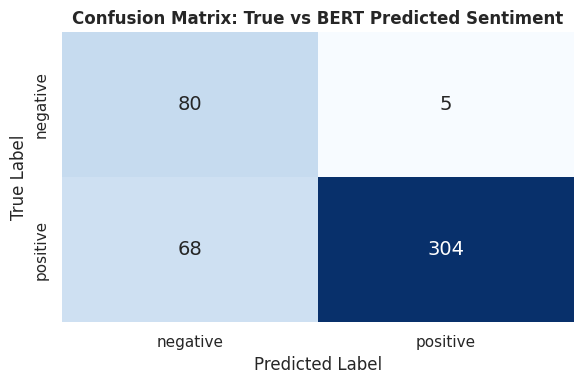

In [11]:
# Confusion matrix: visualize where the model makes errors
labels = ['negative', 'positive']
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    cbar=False, annot_kws={'size': 14}
)
plt.title('Confusion Matrix: True vs BERT Predicted Sentiment', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [12]:
# Error analysis: inspect misclassified examples to understand model limitations
errors = df_eval[df_eval['true_sentiment'] != df_eval['bert_sentiment']]

print(f'Number of misclassified samples: {len(errors)}')
print('=' * 80)
print('Sample misclassified reviews:')
display(errors[['Text', 'true_sentiment', 'bert_sentiment', 'bert_confidence']].head(10))

Number of misclassified samples: 73
Sample misclassified reviews:


,Text,true_sentiment,bert_sentiment,bert_confidence
1,great granola. I saw this at a store for $8 a ...,positive,negative,0.982959
12,The only problem with the Food Cube is that it...,positive,negative,0.999128
19,One of my cats had food allergy. He vomited on...,positive,negative,0.966316
45,"Lucky Country Licorice, Black, is the most lik...",positive,negative,0.999180
50,"It's a bit hard to tell from the listing, but ...",positive,negative,0.590745
52,The biggest impediments to me buying this prod...,positive,negative,0.996492
57,I've tried making recipes from books that use ...,positive,negative,0.998423
62,"My twins love apples and carrots, so this was ...",positive,negative,0.982693
64,I have a labrador retriever. He weighs 82 lbs....,positive,negative,0.998573
73,These are pretty good gingersnaps. They even h...,positive,negative,0.990071


## 9. Visualization

This section provides four plots to understand the results:

1. True vs Predicted sentiment distribution
2. BERT confidence score distribution by sentiment
3. Review length vs true sentiment
4. Confidence score box plot by sentiment

---

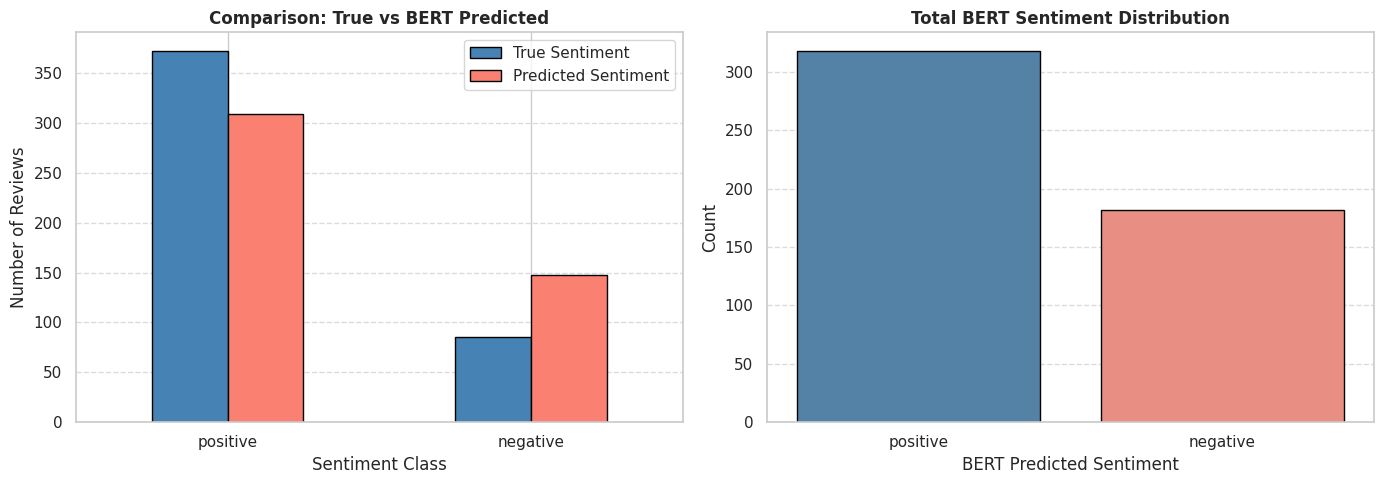

In [13]:
# Plot 1: True vs Predicted sentiment comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart comparing true and predicted counts
eval_counts = pd.DataFrame({
    'True Sentiment': df_eval['true_sentiment'].value_counts(),
    'Predicted Sentiment': df_eval['bert_sentiment'].value_counts()
}).fillna(0)

eval_counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black', ax=axes[0])
axes[0].set_title('Comparison: True vs BERT Predicted', fontweight='bold')
axes[0].set_xlabel('Sentiment Class', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Overall BERT sentiment distribution across the full BERT subset
sns.countplot(
    x='bert_sentiment', data=df_bert,
    palette={'positive': 'steelblue', 'negative': 'salmon'},
    edgecolor='black', ax=axes[1]
)
axes[1].set_title('Total BERT Sentiment Distribution', fontweight='bold')
axes[1].set_xlabel('BERT Predicted Sentiment', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

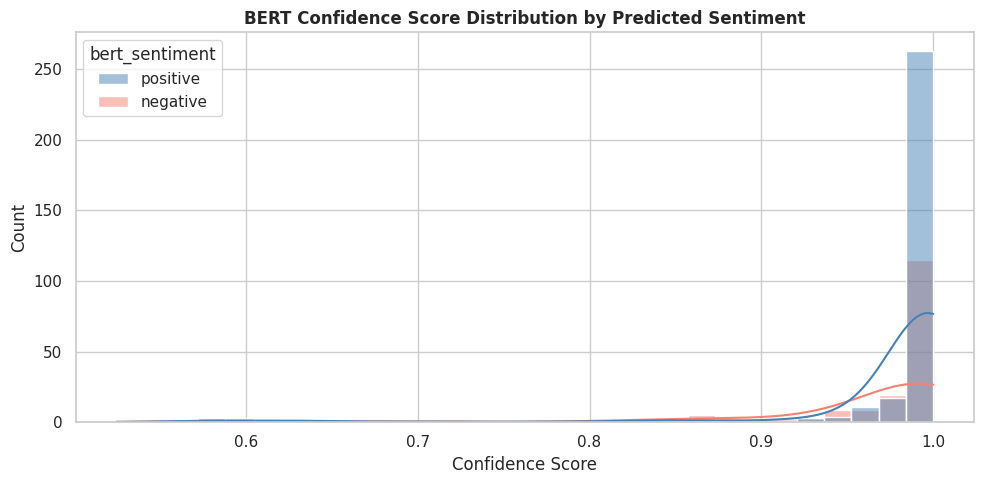

Average confidence by predicted sentiment:
bert_sentiment
negative    0.9562
positive    0.9777
Name: bert_confidence, dtype: float64


In [14]:
# Plot 2: BERT confidence score distribution by predicted sentiment
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_bert,
    x='bert_confidence',
    hue='bert_sentiment',
    bins=30, kde=True,
    palette={'positive': 'steelblue', 'negative': 'salmon'}
)
plt.title('BERT Confidence Score Distribution by Predicted Sentiment', fontweight='bold')
plt.xlabel('Confidence Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Average confidence by predicted sentiment:')
print(df_bert.groupby('bert_sentiment')['bert_confidence'].mean().round(4))

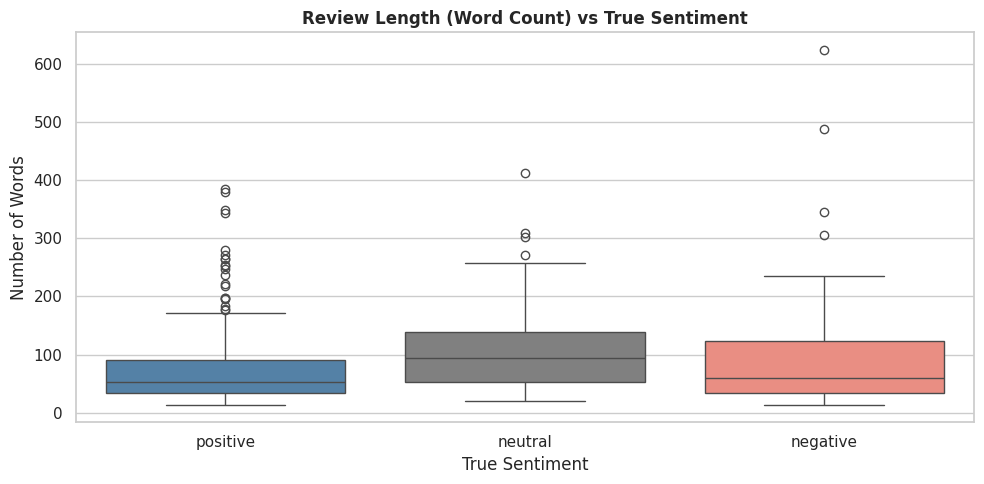

Average review length by sentiment:
true_sentiment
negative     93.6
neutral     112.7
positive     71.6
Name: review_length, dtype: float64


In [15]:
# Plot 3: Review length vs true sentiment
# Negative reviews tend to be longer (customers explain their complaints in more detail)
df_bert['review_length'] = df_bert['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.boxplot(
    x='true_sentiment', y='review_length', data=df_bert,
    order=['positive', 'neutral', 'negative'],
    palette={'positive': 'steelblue', 'neutral': 'gray', 'negative': 'salmon'}
)
plt.title('Review Length (Word Count) vs True Sentiment', fontweight='bold')
plt.xlabel('True Sentiment')
plt.ylabel('Number of Words')
plt.tight_layout()
plt.show()

print('Average review length by sentiment:')
print(df_bert.groupby('true_sentiment')['review_length'].mean().round(1))

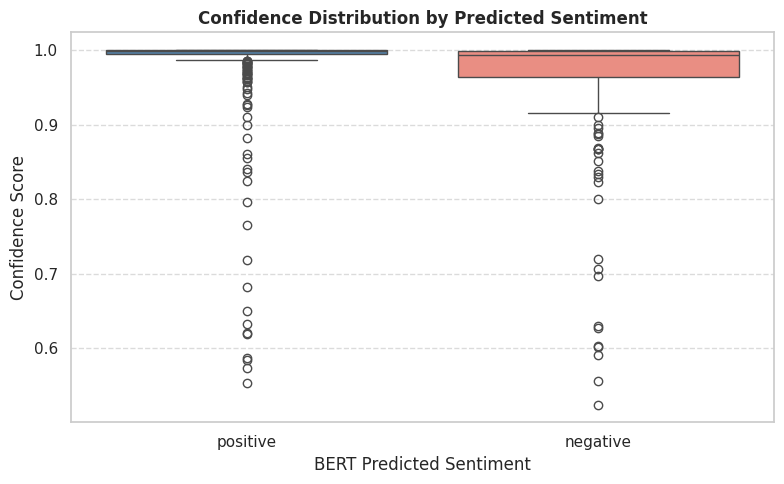

In [16]:
# Plot 4: Confidence distribution box plot by sentiment
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='bert_sentiment', y='bert_confidence', data=df_bert,
    palette={'positive': 'steelblue', 'negative': 'salmon'}
)
plt.title('Confidence Distribution by Predicted Sentiment', fontweight='bold')
plt.xlabel('BERT Predicted Sentiment')
plt.ylabel('Confidence Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10. Business Logic

### Why Sentiment is More Useful Than Rating Alone

A product might have an average 4.0 star rating, but text reviews might reveal a hidden flaw (e.g., "arrived expired"). Analyzing sentiment captures the *actual context* of the user experience.

### Recommendation Logic

To bridge NLP results with the Recommendation Engine (Task 1), we implement a confidence-based business rule:

* **Recommend (1):** Sentiment is `positive` AND confidence is above 0.90.
* **Avoid (0):** Sentiment is `negative` OR confidence is too low.

This ensures the system only promotes items that are both frequently bought and highly praised.

---

In [17]:
# Apply the recommendation logic
# A review is flagged as recommended only if:
# - BERT predicts positive sentiment, AND
# - The confidence score exceeds 0.90 (high certainty)
df_bert['recommended_flag'] = df_bert.apply(
    lambda row: 1 if (row['bert_sentiment'] == 'positive' and row['bert_confidence'] > 0.90) else 0,
    axis=1
)

# Show a sample of the recommendation output
print('Recommendation Logic Applied:')
print('=' * 80)
display(df_bert[['clean_text', 'bert_sentiment', 'bert_confidence', 'recommended_flag']].head(10))


# Business impact summary
total_recommended = df_bert['recommended_flag'].sum()
total_avoided = len(df_bert) - total_recommended

print('\nBusiness Impact Summary:')
print(f'  Products recommended for promotion : {total_recommended} ({(total_recommended/len(df_bert))*100:.1f}%)')
print(f'  Products flagged for quality review: {total_avoided} ({(total_avoided/len(df_bert))*100:.1f}%)')

Recommendation Logic Applied:


,clean_text,bert_sentiment,bert_confidence,recommended_flag
0,"this rice is delicious, well worth the extra m...",positive,0.999871,1
1,great granola. i saw this at a store for $8 a ...,negative,0.982959,0
2,the second star is for the cranberries. howeve...,negative,0.975531,0
3,works better than expected and looks fantastic...,positive,0.999465,1
4,i didn't like these at all! the pancakes came ...,negative,0.999590,0
5,i was intrigued by this product because i love...,negative,0.999272,0
6,i got a sick dog that has to take 5 pills in t...,positive,0.860759,0
7,i have 3 dogs and all three of my dogs will no...,negative,0.999384,0
8,"san francisco bay coffee one cup, rainforest b...",positive,0.992459,1
9,"ok, i cant quite explain why, but for some rea...",positive,0.997213,1



Business Impact Summary:
  Products recommended for promotion : 299 (59.8%)
  Products flagged for quality review: 201 (40.2%)


## 11. Insights

Based on the analysis above, here are the key findings:

**1. The dataset is skewed toward positive reviews.**
Positive reviews make up approximately 78-80% of the full dataset. This reflects a common e-commerce pattern: satisfied customers tend to leave more reviews. This imbalance must be considered when interpreting model performance.

**2. BERT is strong but not perfect.**
BERT performs well on clearly positive and clearly negative reviews, achieving high precision and recall on the binary classification task. However, because it was pre-trained on movie reviews (SST-2), some food-specific language may not transfer perfectly.

**3. The neutral class is a limitation.**
The neutral class (Score 3) is the hardest to handle. BERT outputs only POSITIVE or NEGATIVE, so it cannot classify neutral reviews. Reviews with Score 3 contain genuinely mixed opinions, which causes the most prediction errors.

**4. Errors come from language complexity.**
Misclassifications often involve sarcasm, conditional praise ("good but too salty"), or domain-specific vocabulary that BERT was not fine-tuned on.

**5. Negative reviews tend to be longer.**
Unhappy customers explain their complaints in detail, while satisfied customers often write shorter, simpler reviews.

**6. Confidence is not always reliable.**
BERT shows high confidence on most predictions — even when wrong. High confidence alone should not be treated as a guarantee of correctness.

**7. Sentiment is more useful than rating alone.**
A product may have a 4-star average rating while BERT detects that the text contains a high proportion of negative signals. Text-based sentiment captures context that star ratings cannot.

---

## 12. Business Recommendations

**1. Combine sentiment score with star rating.**
Do not rely on star ratings alone. Use BERT's confidence score as a supplementary signal. A product with a 4.5 average rating and 95% BERT-positive predictions is more trustworthy than one with 4.5 stars but mixed BERT predictions.

**2. Promote high-confidence positive items.**
Surface products with both high average scores (4 or 5 stars) and high BERT-positive prediction rates. These are the safest recommendations.

**3. Deprioritize negatively reviewed items.**
Products where more than 30-40% of BERT predictions are negative should be excluded from top recommendations, regardless of their average star rating.

**4. Handle the neutral class carefully.**
Consider fine-tuning BERT on this specific dataset with a three-class label. Alternatively, treat neutral reviews as low-confidence signals and down-weight them in the recommendation score.

**5. Monitor sentiment trends over time.**
Build a pipeline that re-runs BERT analysis periodically so that recent reviews carry more weight than older ones.

**6. Combine with association rules from Task 1.**
Merge BERT sentiment signals with the Apriori/FP-Growth results from Task 1 to recommend items that are both frequently co-purchased and highly praised.

---

# GUI

In [18]:
import gradio as gr
import pandas as pd
from transformers import pipeline
import re

# =========================
# 1. Load BERT Model
# =========================
print("Loading BERT model...")
bert_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)
print("Model loaded.")

# =========================
# 2. Text Cleaning Function
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# =========================
# 3. Prediction Function
# =========================
def analyze_review(text):
    if not text or len(text.strip()) == 0:
        return pd.DataFrame([{
            "Sentiment": "N/A",
            "Confidence": "0%",
            "Decision": "No Input"
        }])
    
    cleaned = clean_text(text)
    result = bert_pipeline(cleaned)[0]
    
    sentiment = result['label'].lower()
    confidence = result['score']
    
    # Business logic
    if sentiment == "positive" and confidence > 0.90:
        decision = "✅ Recommend"
    elif sentiment == "negative":
        decision = "❌ Avoid"
    else:
        decision = "⚠️ Uncertain"
    
    return pd.DataFrame([{
        "Sentiment": sentiment.capitalize(),
        "Confidence": f"{confidence*100:.2f}%",
        "Decision": decision
    }])

# =========================
# 4. UI Design
# =========================
custom_theme = gr.themes.Soft()

with gr.Blocks(theme=custom_theme, title="Food Review Sentiment Analyzer") as demo:
    
    gr.Markdown("""
    <div style="text-align: center;">
        <h1>🍽️ Food Review Sentiment Analyzer</h1>
        <p>Powered by BERT (HuggingFace Transformers)</p>
    </div>
    """)
    
    with gr.Row():
        
        # INPUT
        with gr.Column(scale=1):
            gr.Markdown("### ✍️ Enter Review")
            
            review_input = gr.Textbox(
                lines=6,
                placeholder="Write your food review here...",
                label="Customer Review"
            )
            
            analyze_btn = gr.Button("Analyze 🔍", variant="primary")
        
        # OUTPUT
        with gr.Column(scale=1):
            gr.Markdown("### 🤖 Analysis Result")
            
            output_table = gr.Dataframe(
                headers=["Sentiment", "Confidence", "Decision"],
                interactive=False
            )
    
    analyze_btn.click(
        fn=analyze_review,
        inputs=review_input,
        outputs=output_table
    )

demo.launch(share=True)

Loading BERT model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://20ef3ba95021ddd447.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# BERT Sentiment Analysis - Test Cases

## Positive Reviews (Expected: Recommend)

```
This product is amazing! I absolutely love the taste and quality.
```

```
Best snack I have ever tried. Will definitely buy again!
```

```
Very fresh and delicious, exceeded my expectations.
```

---

## Negative Reviews (Expected: Avoid)

```
This product is terrible. It tastes awful and smells bad.
```

```
Completely disappointed. Waste of money.
```

```
The quality is very poor and it arrived expired.
```

---

## Mixed / Uncertain Reviews (Expected: Uncertain)

```
The taste is good but the texture is weird.
```

```
Not bad, but I wouldn't buy it again.
```

```
It's okay, nothing special.
```

---

## Sarcasm / Tricky Cases (Model Limitations)

```
Great, just great... arrived broken as always.
```

```
I love wasting money on bad products like this.
```

---

## Short Inputs (Edge Cases)

```
Good
```

```
Bad
```

```
Nice
```

---

## Real Food Reviews (Recommended for Demo)

```
The chocolate flavor is rich and creamy. My kids loved it!
```

```
Too salty and the portion size is very small.
```

```
Fresh vegetables and good packaging. Highly recommended.
```

---

## Edge Cases (Robustness Testing)

### Empty Input

```
```

### Random Text

```
asdfghjkl
```

### Numbers Only

```
123456789
```

---

## Critical Logic Test (Negation Understanding)

```
This product is good
```

```
This product is not good
```

---

## Notes

* Positive sentiment with high confidence should lead to recommendation.
* Negative sentiment should lead to avoidance.
* Mixed or low-confidence results should be treated as uncertain.
* Sarcasm and complex language may lead to misclassification, which is a known limitation of the model.

---


## 13. Conclusion

In [19]:
# Final summary of the analysis
print('=' * 60)
print('ANALYSIS SUMMARY')
print('=' * 60)
print(f'Total dataset size        : {len(df):,} rows')
print(f'Sampled dataset size      : {len(df_sampled):,} rows')
print(f'BERT applied on           : {BERT_SUBSET} rows')
print(f'Evaluation set size       : {len(df_eval)} rows (positive + negative only)')
print()
print('BERT Predicted Sentiment Distribution:')
print(df_bert['bert_sentiment'].value_counts().to_string())
print()
print('Average BERT Confidence   :', round(df_bert['bert_confidence'].mean(), 4))
print('=' * 60)

ANALYSIS SUMMARY
Total dataset size        : 568,454 rows
Sampled dataset size      : 2,999 rows
BERT applied on           : 500 rows
Evaluation set size       : 457 rows (positive + negative only)

BERT Predicted Sentiment Distribution:
bert_sentiment
positive    318
negative    182

Average BERT Confidence   : 0.9699


### What Was Done

We loaded and cleaned a large dataset of food product reviews, converted star ratings into sentiment labels, applied minimal text preprocessing, and used a pre-trained BERT model from HuggingFace to predict the sentiment of 500 reviews. We then evaluated performance using classification reports and confusion matrices, and created visualizations to understand data patterns.

### What Was Achieved

BERT demonstrated strong performance on the binary sentiment classification task (positive vs. negative), correctly identifying the emotional tone of most reviews. The analysis revealed important patterns including class imbalance, the challenge of neutral reviews, and the tendency of negative reviews to be longer and more detailed.

### How This Supports the Project

This task provides the sentiment intelligence layer for the overall recommendation system project. By understanding not just how many stars a product received but also the language and confidence of customer opinions, the recommendation system can make smarter, more reliable suggestions. The BERT-derived sentiment scores can be directly integrated as features in a larger recommendation engine, helping recommend better products, filter out poor ones, and ultimately improve the customer experience.